In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

df['SIMPLE_RETURNS'] = simple_returns(close)
df['LOG_RETURNS'] = log_returns(close)
df['SMA_20'] = sma(close, window=20)
df['EMA_20'] = ema(close, span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

df[['Close', 'SMA_20', 'EMA_20']].plot(title='FTSE Closing Price with SMA and EMA')
plt.show()

print(type(close))
print(close.head())
position = donchian_breakout_position(close, lookback=20)

# Backtest with and without borrow costs
bt_no_borrow = backtest_log_returns(close, position, cost_per_trade=0.001)
bt_with_borrow = backtest_log_returns(close, position, cost_per_trade=0.001, borrow_cost=0.02)  # 2% annual borrow cost

print("\n--- Position Analysis ---")
print(position.value_counts())  # Count of each position type (-1, 0, 1)
print(f"Percentage of time SHORT: {(position == -1).sum() / len(position) * 100:.2f}%")
print(f"Percentage of time LONG: {(position == 1).sum() / len(position) * 100:.2f}%")

buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

print("\n--- Performance Comparison ---")
print(f"Strategy final equity (no borrow): {bt_no_borrow['equity'].iloc[-1]:.4f}")
print(f"Strategy final equity (with borrow): {bt_with_borrow['equity'].iloc[-1]:.4f}")
print(f"Buy & hold final equity: {buy_hold_equity.iloc[-1]:.4f}")
print(f"Total trades executed: {bt_no_borrow['trade'].sum():.0f}")
print(f"Max Drawdown (no borrow): {bt_no_borrow['drawdown'].min()*100:.2f}%")
print(f"Max Drawdown (with borrow): {bt_with_borrow['drawdown'].min()*100:.2f}%")

print(generate_trade_log(bt_no_borrow))

plt.figure(figsize=(12, 6))
plt.plot(bt_no_borrow["equity"], label="MA Strategy (no borrow cost)", linewidth=2)
plt.plot(bt_with_borrow["equity"], label="MA Strategy (2% borrow cost)", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.legend()
plt.title("Strategy vs Buy & Hold (With and Without Borrow Costs)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12, 6))
# plt.plot(bt_no_borrow["drawdown"]*100, label="MA Strategy (no borrow cost)", linewidth=2)
# plt.plot(bt_with_borrow["drawdown"]*100, label="MA Strategy (2% borrow cost)", linewidth=2)
# plt.legend()
# plt.title("Drawdown Comparison")
# plt.ylabel("Drawdown (%)")
# plt.xlabel("Date")
# plt.grid(True, alpha=0.3)
# plt.show()

print("\n--- Performance Metrics (No Borrow Cost) ---")
print(evaluate_performance(bt_no_borrow))
print("\n--- Performance Metrics (With Borrow Cost) ---")
print(evaluate_performance(bt_with_borrow))

print(position.value_counts())
print(position.head(30))
print(bt_no_borrow[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
print(bt_no_borrow['strat_log'].isna().sum(), "NaN strat_log values")
print(bt_no_borrow['equity'].isna().sum(), "NaN equity values")

print(bt_no_borrow[bt_no_borrow['position'] != bt_no_borrow['position'].shift(1)][['close','position']].head(20))


In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

print(type(close))
print(close.head())
# for lb in [10, 20, 40, 60]:
#     position = donchian_breakout_position(close, lookback=lb, threshold=0.0)
#     bt = backtest_log_returns(close, position, cost_per_trade=0.001)
#     print(f"lookback={lb}  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

# position = donchian_breakout_position(close, lookback=40, threshold=0.0)
# bt = backtest_log_returns(close, position, cost_per_trade=0.001)
# print(f"Donchian Breakout Strategy (lookback=40)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

# position_long_only = position.clip(lower=0)  # Convert to long-only by setting short positions to 0
# bt_long_only = backtest_log_returns(close, position_long_only, cost_per_trade=0.001)

for ticker in ["AAPL", "SPY"]:
    close = load_prices(ticker, "2023-06-01", "2026-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    position = donchian_breakout_position(close, lookback=10, threshold=0.05)
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)
    print(f"{ticker} Donchian Breakout Strategy (lookback=10, threshold=0.05)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

    buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

    plt.figure(figsize=(12, 6))
    plt.plot(bt["equity"], label=f"{ticker} Donchian Breakout Equity", linewidth=2)
    plt.plot(buy_hold_equity, label=f"{ticker} Buy & Hold Equity", linewidth=2)
    plt.title(f"{ticker} Donchian Breakout Strategy Equity Curve")
    plt.ylabel("Equity")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n Performance Metrics ---")
    print(evaluate_performance(bt))

    print(position.value_counts())
    print(position.head(30))
    print(bt[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
    print(bt['strat_log'].isna().sum(), "NaN strat_log values")
    print(bt['equity'].isna().sum(), "NaN equity values")

    print("\n Trade Log ---")
    tl = generate_trade_log(bt, vol_window=20, trend_window=20)
    print(tl)

    


--- All Results (sorted by Sharpe) ---
Ticker  Fast  Slow    Return    Sharpe  Drawdown  Trades
   SPY    10    90  0.132664  0.326449 -0.166430    15.0
   SPY    10    95  0.129368  0.319494 -0.171676    15.0
   SPY    15    95  0.109223  0.273324 -0.169790    15.0
   SPY    20    80  0.103884  0.259782 -0.155561    15.0
   SPY    15    90  0.103049  0.258129 -0.169790    15.0
   SPY    10   100  0.097276  0.244854 -0.171676    15.0
   SPY    20    95  0.093188  0.237533 -0.159215    15.0
   SPY    20    90  0.089478  0.228050 -0.159215    15.0
   SPY    10    35  0.089521  0.227088 -0.156479    24.0
   SPY    25    70  0.089568  0.226544 -0.152167    15.0
   SPY    10    30  0.086968  0.221575 -0.152454    24.0
   SPY    10    85  0.087223  0.218307 -0.166430    15.0
   SPY    45    65  0.081362  0.207617 -0.155256    17.0
   SPY    50    60  0.078300  0.203959 -0.161366    23.0
   SPY    20    75  0.079691  0.200915 -0.169790    15.0
   SPY    50    65  0.077451  0.199210 -0.160018

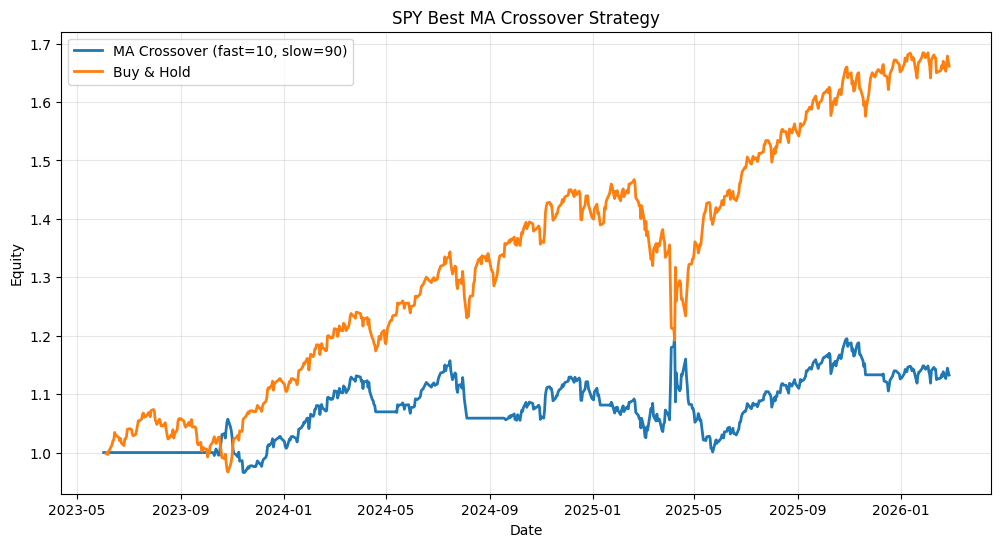

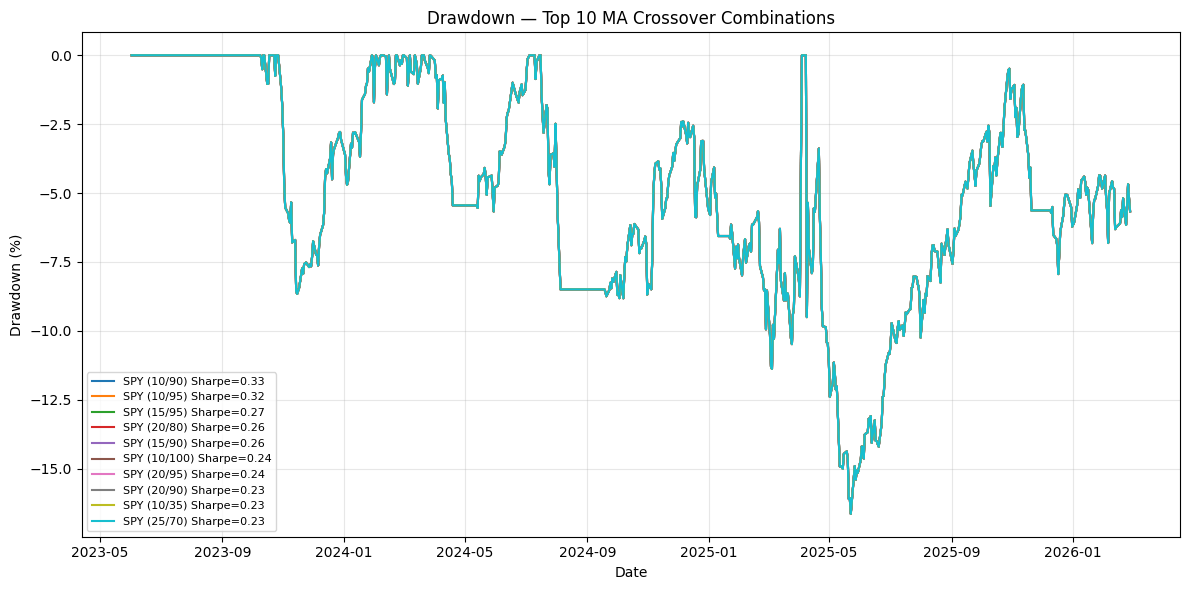

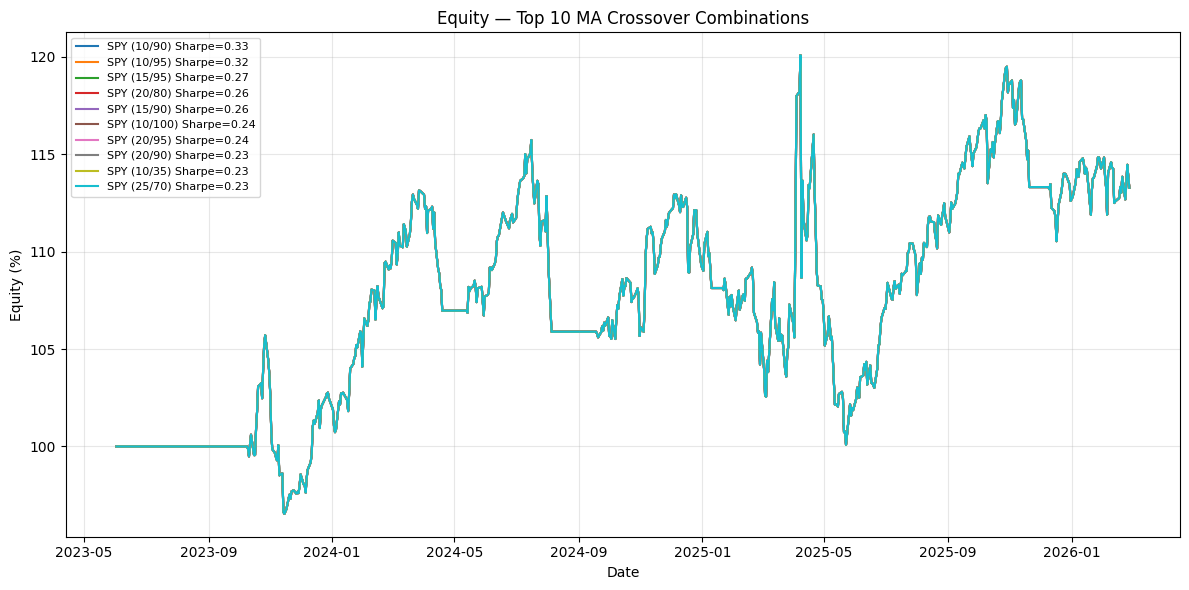

entries: 8, exits: 7
  Entry Time  Exit Time Direction  Entry Price  Exit Price  Log Return  \
0 2023-10-10 2023-11-14     Short   421.194214  434.948425   -0.032133   
1 2023-11-15 2024-04-19      Long   435.869232  483.395630    0.103493   
2 2024-05-14 2024-08-05      Long   510.867065  506.717163   -0.008156   
3 2024-09-19 2025-01-10      Long   559.212463  572.189636    0.022941   
4 2025-01-22 2025-03-04      Long   597.768616  568.611572   -0.050006   
5 2025-03-05 2025-05-12     Short   574.722900  576.382629   -0.002884   
6 2025-05-15 2025-11-20      Long   583.768005  648.835571    0.105676   
7 2025-12-10 2026-02-27      Long   683.677185  684.121643    0.000650   

    Return %  Duration Bars  Duration Days  Trend Strength  \
0  35.624613             25             35        0.003734   
1  40.799235            106            156        0.048534   
2  36.489106             56             83        0.027833   
3  37.641651             77            113        0.024819   
4 

In [23]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.engine.backtest import backtest_log_returns
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log
import matplotlib.pyplot as plt

windows = [
    (fast, slow)
    for fast in range(10, 51, 5)
    for slow in range(20, 101, 5)
    if slow > fast
]
results = []

for ticker in ["SPY"]:
    close = load_prices(ticker, "2023-06-01", "2026-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    buy_hold_equity = np.exp(log_returns(close).cumsum())

    for fast, slow in windows:

        pos_ma       = ma_crossover_position(close, fast_window=fast, slow_window=slow)
        pos_donchian = donchian_breakout_position(close, lookback=40)

        position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
        np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
        position = pd.Series(position, index=close.index, dtype=float)

        bt = backtest_log_returns(close, position, cost_per_trade=0.001)
        perf = evaluate_performance(bt)

        results.append({
            'Ticker':    ticker,
            'Fast':      fast,
            'Slow':      slow,
            'Return':    perf['Total Return'],
            'Sharpe':    perf['Sharpe Ratio'],
            'Drawdown':  perf['Max Drawdown'],
            'Trades':    perf['Total Trades Executed'],
        })

# Build results table
results_df = pd.DataFrame(results).sort_values('Sharpe', ascending=False)
print("\n--- All Results (sorted by Sharpe) ---")
print(results_df.to_string(index=False))

print("\n--- Filtered Results (Drawdown > -20%, Sharpe > 0.5, Positive Return) ---")
filtered = results_df[
    (results_df["Drawdown"] > -0.20) &
    (results_df["Sharpe"]   >  0.50) &
    (results_df["Return"]   >  0.00)
].sort_values("Sharpe", ascending=False)

if filtered.empty:
    print("No combinations met the filter criteria — consider relaxing the thresholds")
else:
    print(filtered.to_string(index=False))
# ---- END ----

# Best by Sharpe (from filtered if available, otherwise full results)
best_pool = filtered if not filtered.empty else results_df
best = best_pool.iloc[0]
print(f"\n--- Best Combination ---")
print(f"Ticker: {best['Ticker']}  Fast: {int(best['Fast'])}  Slow: {int(best['Slow'])}")
print(f"Sharpe: {best['Sharpe']:.3f}  Return: {best['Return']:.3f}  Drawdown: {best['Drawdown']:.3f}")

# Plot the best
close = load_prices(best['Ticker'], "2023-06-01", "2026-03-01")["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[1:, 0]



pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
pos_donchian = donchian_breakout_position(close, lookback=40)

position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
           np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
position = pd.Series(position, index=close.index, dtype=float)

bt = backtest_log_returns(close, position, cost_per_trade=0.001)
buy_hold_equity = np.exp(log_returns(close).cumsum())

plt.figure(figsize=(12, 6))
plt.plot(bt["equity"], label=f"MA Crossover (fast={int(best['Fast'])}, slow={int(best['Slow'])})", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.title(f"{best['Ticker']} Best MA Crossover Strategy")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# top ten drawdown-filtered by Sharpe (or overall if none passed filters)

top10 = filtered.head(10) if not filtered.empty else results_df.head(10)

plt.figure(figsize=(12, 6))

for _, row in top10.iterrows():
    close = load_prices(row['Ticker'], "2023-06-01", "2026-03-01")["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
    pos_donchian = donchian_breakout_position(close, lookback=40)

    position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
               np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
    position = pd.Series(position, index=close.index, dtype=float)
    
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)

    label = f"{row['Ticker']} ({int(row['Fast'])}/{int(row['Slow'])}) Sharpe={row['Sharpe']:.2f}"
    plt.plot(bt["drawdown"] * 100, label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Drawdown — Top 10 MA Crossover Combinations")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# top ten equity curves

top10 = filtered.head(10) if not filtered.empty else results_df.head(10)

plt.figure(figsize=(12, 6))

for _, row in top10.iterrows():
    close = load_prices(row['Ticker'], "2023-06-01", "2026-03-01")["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
    pos_donchian = donchian_breakout_position(close, lookback=40)

    position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
                np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
    position = pd.Series(position, index=close.index, dtype=float)
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)

    label = f"{row['Ticker']} ({int(row['Fast'])}/{int(row['Slow'])}) Sharpe={row['Sharpe']:.2f}"
    plt.plot(bt["equity"] * 100, label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Equity — Top 10 MA Crossover Combinations")
plt.ylabel("Equity (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(generate_trade_log(bt, vol_window=20, trend_window=20))